# Topic Modeling Profiles (Female-Focused & Character-Centric)

This notebook loads the pre-computed topic modeling results from `data/topic_modelling/final_model/` and generates the visualizations required for the report.

To align with the paper's framing of "feminine narratives of opium use" and to keep the figures visually distinct, compact, and ready for publication (no titles, as they are described in captions), we generate four key figures:
1. **Character Topic Gender Divergence**: A horizontal bar chart showing the difference in topic shares between Male and Female characters (`Male Character % - Female Character %`), showcasing the character-level gender gap.
2. **Author Gender Divergence for Female Characters**: A horizontal bar chart showing the difference in topic shares for **Female Characters** specifically between Female and Male Authors (`Female Author % - Male Author %`).
3. **Geography Divergence for Female Characters**: A horizontal bar chart showing the difference in topic shares for **Female Characters** specifically between British and American literature (`British % - American %`).
4. **Temporal Evolution of Selected Topics for Female Characters**: A line plot showing how the ten labeled topics evolve chronologically specifically for **Female Characters** over the three historical periods (1850–1930).

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set up clean aesthetic style
sns.set_theme(style='whitegrid', context='paper')
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 12,
    'axes.labelsize': 13,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 11
})

def format_topic_label(label, max_words=3):
    """Formats the topic label to look clean in figures (e.g. 'Topic 12: captain, ship, colonel...')"""
    parts = label.split(': ')
    if len(parts) != 2:
        return label
    topic_num = parts[0]
    words = parts[1].split(', ')
    words_truncated = ', '.join(words[:max_words])
    if len(words) > max_words:
        words_truncated += '...'
    return f"Topic {topic_num} ({words_truncated})"
%matplotlib inline

## 1) Topic Divergence by Character Gender (The Gender Gap)

In [42]:
female_color = "#E05B5B"
male_color = "#4A90D9"


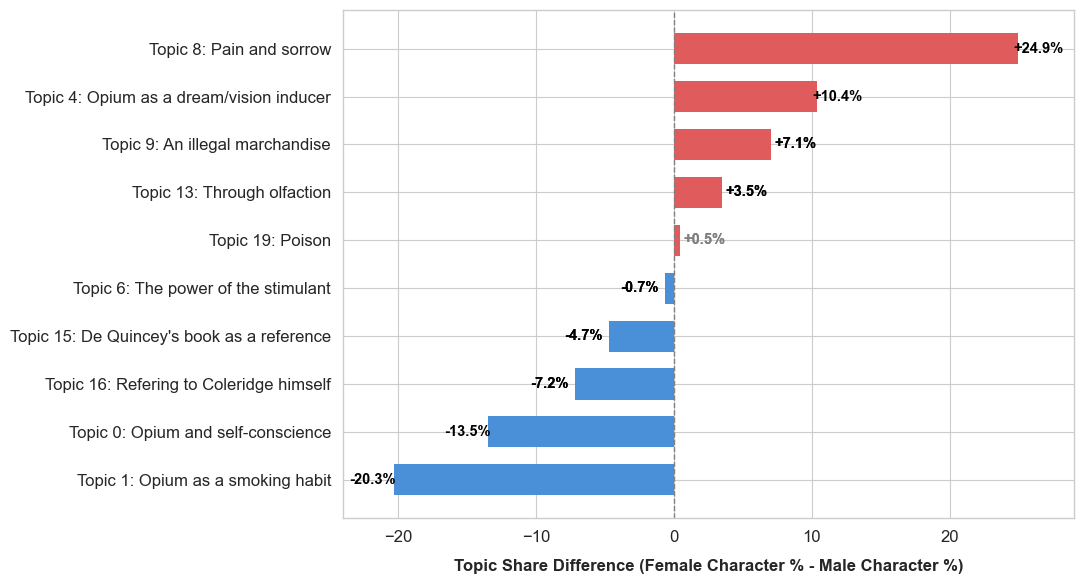

In [68]:
df_assigned = pd.read_csv('../../data/topic_modelling/final_model/final_topics_by_assigned_gender.csv')
df_assigned["Assigned_Gender_Group"] = df_assigned["Assigned_Gender_Group"].fillna("Unknown").replace("", "Unknown").astype(str).str.strip()
df_assigned = df_assigned[df_assigned['bertopic_topic'] != -1]  # Exclude outliers

df_gender_clean = df_assigned[df_assigned['Assigned_Gender_Group'].isin(['Male', 'Female'])]
pivot_gender = df_gender_clean.pivot(index='topic_label', columns='Assigned_Gender_Group', values='topic_share').fillna(0)
pivot_gender['diff'] = (pivot_gender['Female'] - pivot_gender['Male']) * 100

top_male = pivot_gender.sort_values('diff', ascending=False).head(8)
top_female = pivot_gender.sort_values('diff', ascending=True).head(8)
divergence_df = pd.concat([top_male, top_female]).sort_values('diff', ascending=False)

#divergence_df.index = [format_topic_label(label) for label in divergence_df.index]

fig, ax = plt.subplots(figsize=(11, 6))
colors = [female_color if val >= 0 else male_color for val in divergence_df['diff']]
bars = ax.barh(divergence_df.index, divergence_df['diff'], color=colors, edgecolor='none', height=0.65)

ax.axvline(0, color='gray', linestyle='--', linewidth=1)
ax.set_xlabel('Topic Share Difference (Female Character % - Male Character %)', fontsize=12, fontweight='bold', labelpad=10)
ax.invert_yaxis()
ax.set_xlim(-24, 29)
ax.tick_params(axis='both', which='major', labelsize=12)

for bar in bars:
    width = bar.get_width()
    align = 'left' if width < 0 else 'right'
    offset = -3.2 if width < 0 else 3.3
    ax.text(width + offset, bar.get_y() + bar.get_height()/2, f"{width:+.1f}%", 
            va='center', ha=align, fontsize=10.5, fontweight='semibold',
            color='black' if abs(width) > 0.5 else 'gray')

plt.tight_layout()
plt.savefig('../../data/snippets/topic_gender_divergence.png', dpi=200, bbox_inches='tight')
plt.show()

## 2) Topic Divergence by Author Gender for Female Characters

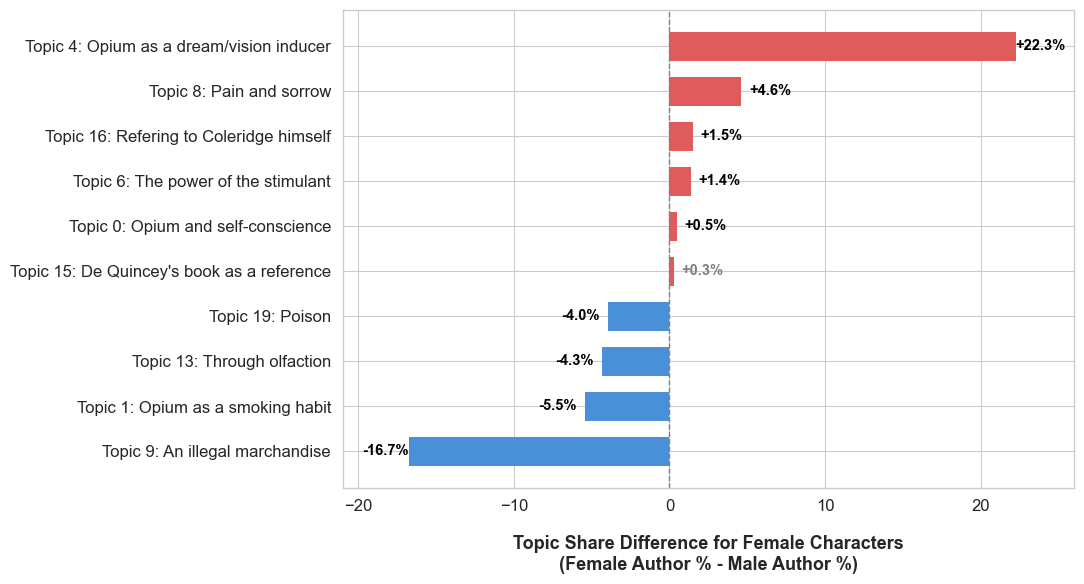

In [65]:
df_raw = pd.read_csv('../../data/topic_modelling/final_model/sentence_context_bertopic_tuned_final_document_topics.csv')
df_raw["Author_Gender_Group"] = df_raw["Author Gender"].fillna("Unknown").replace("", "Unknown").astype(str).str.strip().str.lower()
df_raw["Assigned_Gender_Group"] = df_raw["Assigned_Gender"].fillna("Unknown").replace("", "Unknown").astype(str).str.strip()

SELECTED_TOPIC_LABELS = {
    0: "Topic 0: Opium and self-conscience",
    1: "Topic 1: Opium as a smoking habit",
    4: "Topic 4: Opium as a dream/vision inducer",
    6: "Topic 6: The power of the stimulant",
    8: "Topic 8: Pain and sorrow",
    9: "Topic 9: An illegal marchandise",
    13: "Topic 13: Through olfaction",
    15: "Topic 15: De Quincey's book as a reference",
    16: "Topic 16: Refering to Coleridge himself",
    19: "Topic 19: Poison",
}

df_female_author = df_raw[
    (df_raw["Assigned_Gender_Group"] == "Female") &
    (df_raw["bertopic_topic"].isin(SELECTED_TOPIC_LABELS)) &
    (df_raw["Author_Gender_Group"].isin(["male", "female"]))
].copy()

df_female_author['topic_label'] = df_female_author['bertopic_topic'].map(SELECTED_TOPIC_LABELS)

grouped_author = df_female_author.groupby(['Author_Gender_Group', 'topic_label']).size().unstack(fill_value=0)
totals_author = df_female_author.groupby('Author_Gender_Group').size()
shares_author = (grouped_author.div(totals_author, axis=0) * 100).T
shares_author['diff'] = shares_author['female'] - shares_author['male']

author_df = shares_author.sort_values('diff', ascending=False)

fig, ax = plt.subplots(figsize=(11, 6))
colors = [female_color if val >= 0 else male_color for val in author_df['diff']]
bars = ax.barh(author_df.index, author_df['diff'], color=colors, edgecolor='none', height=0.65)

ax.axvline(0, color='gray', linestyle='--', linewidth=1)
ax.set_xlabel('Topic Share Difference for Female Characters\n(Female Author % - Male Author %)', fontsize=13, fontweight='bold', labelpad=15)
ax.invert_yaxis()
max_abs_diff = author_df['diff'].abs().max()
ax.set_xlim(-21, 26)
ax.tick_params(axis='both', which='major', labelsize=12)

for bar in bars:
    width = bar.get_width()
    align = 'left' if width < 0 else 'right'
    offset = -3 if width < 0 else 3.2
    ax.text(width + offset, bar.get_y() + bar.get_height()/2, f"{width:+.1f}%", 
            va='center', ha=align, fontsize=10.5, fontweight='semibold',
            color='black' if abs(width) > 0.3 else 'gray')

plt.tight_layout()
plt.savefig('../../data/snippets/topic_author_divergence.png', dpi=200, bbox_inches='tight')
plt.show()

## 3) Topic Geography Divergence for Female Characters (British vs. American)

In [47]:
uk_color = "#1F4E79"   # deep navy / Union Jack blue
us_color = "#B22234"   # muted American flag red

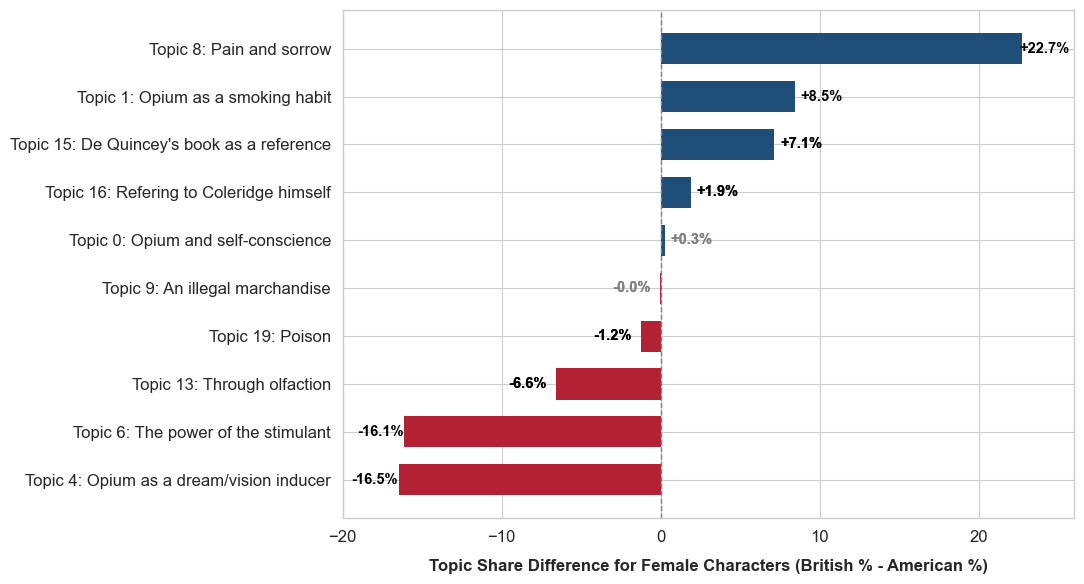

In [60]:
df_combined = pd.read_csv('../../data/topic_modelling/final_model/final_topics_by_assigned_gender_locc_period.csv')
df_combined["Assigned_Gender_Group"] = df_combined["Assigned_Gender_Group"].fillna("Unknown").replace("", "Unknown").astype(str).str.strip()
df_combined = df_combined[df_combined['bertopic_topic'] != -1]  # Exclude outliers

df_female_locc = df_combined[
    (df_combined["Assigned_Gender_Group"] == "Female") &
    (df_combined["LoCC_Display"].isin(["PR", "PS"]))
].copy()

pivot_locc = df_female_locc.pivot_table(index='topic_label', columns='LoCC_Display', values='topic_share', aggfunc='sum').fillna(0)
pivot_locc['diff'] = (pivot_locc['PR'] - pivot_locc['PS']) * 100

top_pr = pivot_locc.sort_values('diff', ascending=False).head(8)
top_ps = pivot_locc.sort_values('diff', ascending=True).head(8)
locc_df = pd.concat([top_pr, top_ps]).sort_values('diff', ascending=False)

#locc_df.index = [format_topic_label(label) for label in locc_df.index]

fig, ax = plt.subplots(figsize=(11, 6))
colors = [uk_color if val >= 0 else us_color for val in locc_df['diff']]
bars = ax.barh(locc_df.index, locc_df['diff'], color=colors, edgecolor='none', height=0.65)

ax.axvline(0, color='gray', linestyle='--', linewidth=1)
ax.set_xlabel('Topic Share Difference for Female Characters (British % - American %)', fontsize=12, fontweight='bold', labelpad=10)
ax.invert_yaxis()
ax.set_xlim(-20, 26)
ax.tick_params(axis='both', which='major', labelsize=12)

for bar in bars:
    width = bar.get_width()
    align = 'left' if width < 0 else 'right'
    offset = -3 if width < 0 else 3
    ax.text(width + offset, bar.get_y() + bar.get_height()/2, f"{width:+.1f}%", 
            va='center', ha=align, fontsize=10.5, fontweight='semibold',
            color='black' if abs(width) > 1.0 else 'gray')

plt.tight_layout()
plt.savefig('../../data/snippets/topic_locc_comparison.png', dpi=200, bbox_inches='tight')
plt.show()

## 4) Historical Evolution of Selected Topics for Female Characters

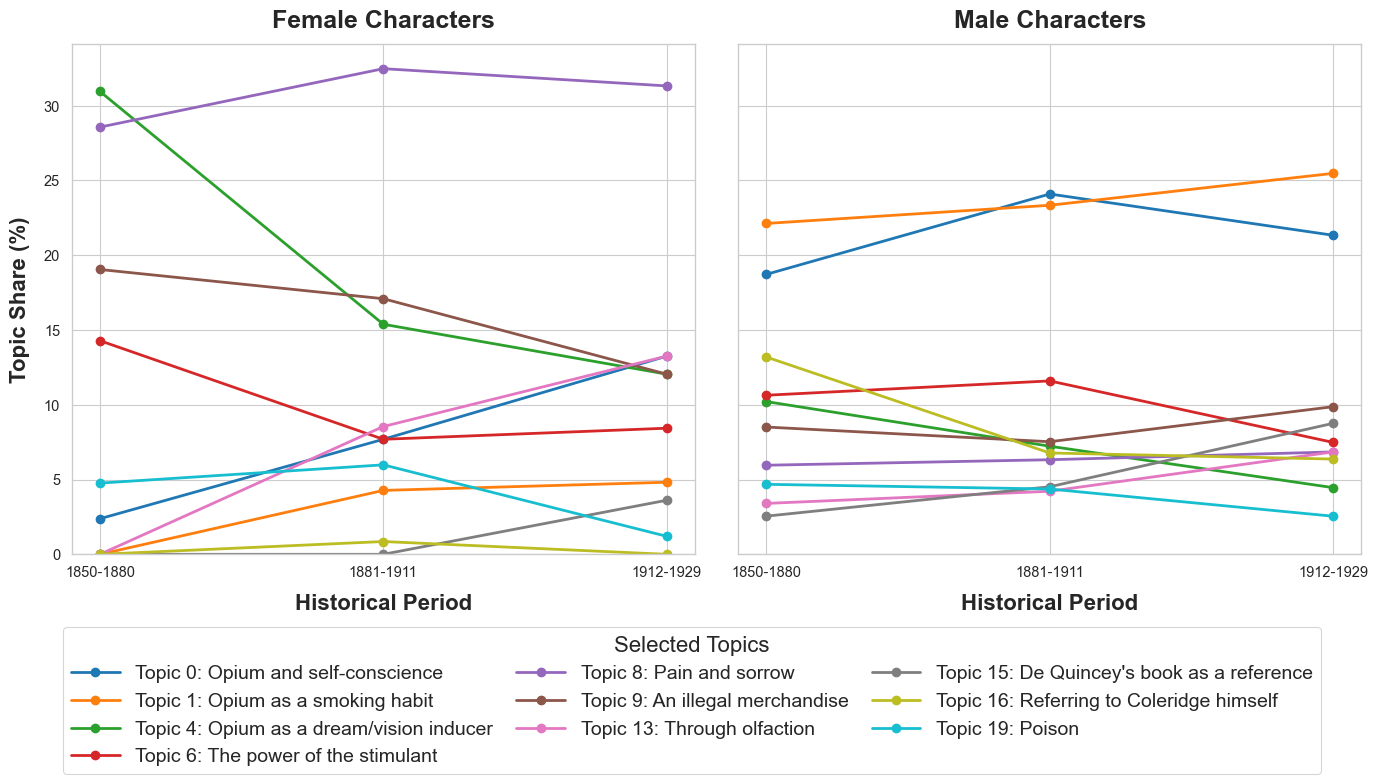

In [79]:
df_period_topics = pd.read_csv(
    "../../data/topic_modelling/final_model/"
    "sentence_context_bertopic_tuned_final_document_topics.csv"
)

df_period_topics["Assigned_Gender_Group"] = (
    df_period_topics["Assigned_Gender"]
    .fillna("Unknown")
    .replace("", "Unknown")
    .astype(str)
    .str.strip()
)

SELECTED_TOPIC_LABELS = {
    0: "Topic 0: Opium and self-conscience",
    1: "Topic 1: Opium as a smoking habit",
    4: "Topic 4: Opium as a dream/vision inducer",
    6: "Topic 6: The power of the stimulant",
    8: "Topic 8: Pain and sorrow",
    9: "Topic 9: An illegal merchandise",
    13: "Topic 13: Through olfaction",
    15: "Topic 15: De Quincey's book as a reference",
    16: "Topic 16: Referring to Coleridge himself",
    19: "Topic 19: Poison",
}

period_order = ["1850-1880", "1881-1911", "1912-1929"]

df_period_topics["Period"] = pd.cut(
    df_period_topics["Published Year"],
    bins=[1849, 1880, 1911, 1929],
    labels=period_order,
)

def get_topic_shares(gender):
    df_gender_period = df_period_topics[
        (df_period_topics["Assigned_Gender_Group"] == gender) &
        (df_period_topics["bertopic_topic"].isin(SELECTED_TOPIC_LABELS))
    ].copy()

    df_gender_period["topic_label"] = (
        df_gender_period["bertopic_topic"].map(SELECTED_TOPIC_LABELS)
    )

    grouped_period = (
        df_gender_period.groupby(["Period", "topic_label"], observed=False)
        .size()
        .unstack(fill_value=0)
        .reindex(
            index=period_order,
            columns=list(SELECTED_TOPIC_LABELS.values()),
            fill_value=0,
        )
    )

    period_totals = grouped_period.sum(axis=1)

    return (
        grouped_period
        .div(period_totals.where(period_totals.ne(0)), axis=0)
        .mul(100)
        .fillna(0)
    )

shares_by_gender = {
    "Female": get_topic_shares("Female"),
    "Male": get_topic_shares("Male"),
}

colors = dict(
    zip(
        SELECTED_TOPIC_LABELS.values(),
        sns.color_palette("tab10", n_colors=len(SELECTED_TOPIC_LABELS)),
    )
)

fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(14, 8),
    sharey=True,
)

for ax, gender in zip(axes, ["Female", "Male"]):
    shares = shares_by_gender[gender]

    for topic_label in shares.columns:
        ax.plot(
            shares.index,
            shares[topic_label],
            marker="o",
            linewidth=2,
            markersize=6,
            color=colors[topic_label],
            label=topic_label,
        )

    ax.set_title(
        f"{gender} Characters",
        fontsize=18,
        fontweight="bold",
        pad=12,
    )
    ax.set_xlabel(
        "Historical Period",
        fontsize=16,
        fontweight="bold",
        labelpad=10,
    )
    ax.set_ylim(bottom=0)
    ax.tick_params(axis="both", which="major", labelsize=10.5)

axes[0].set_ylabel(
    "Topic Share (%)",
    fontsize=16,
    fontweight="bold",
    labelpad=10,
)

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    title="Selected Topics",
    title_fontsize=16,
    fontsize=14,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.01),
    ncol=3,
    frameon=True,
    columnspacing=1.2,
    handlelength=2.5,
)

plt.tight_layout(rect=[0, 0.2, 1, 1])

plt.savefig(
    "../../data/snippets/topic_temporal_evolution_by_gender.png",
    dpi=200,
    bbox_inches="tight",
)

plt.show()